# Campaign Category Reactivation Analysis

## What this notebook answers

Which campaign categories are actually driving client reactivation, across
Lapsed, Dormant, and Dormant 3+ year clients? This notebook focuses entirely on
**category-level** comparisons — it takes every send that IS NOT APEC, DSE, FLS, 
or transactional/account-service email, and breaks it apart into its actual,
identifiable components.

## Decomposing Non-Personalized Campaigns

Inspecting the actual campaign names that ARE NOT APEC, DSE, or FLS turned
up several distinct, identifiable groups mixed in with generic seasonal/thematic
marketing content:

- **Promotional and incentive-based sends** — campaign names referencing an
  offer, discount, sale, credit, incentive, or a waived styling fee. These
  use a financial incentive as the mechanism, which is a fundamentally
  different lever than message personalization or content.
- **Reactivation/win-back messaging without a financial incentive** —
  campaigns explicitly named for re-engaging a client, but without an
  offer or credit attached.
- **Birthday** and **post-Fix cross-sell** sends — narrow, clearly-named
  send types with their own distinct intent.
- **A non-marketing tracking artifact** (`crumbs_has_app`) — a single,
  uniform internal event tag (not a real campaign with real creative
  content).

Splitting these out changes the picture. Pooled across all three client
lifecycle states, over the full analysis window:

| Category | Clients sent | Reactivated | Reactivation rate |
|---|---|---|---|
| TRANSACTIONAL | 2,590,264 | 79,503 | 3.0693% |
| DSE | 3,949,149 | 39,972 | 1.0122% |
| FLS | 279,216 | 2,169 | 0.7768% |
| PROMO_INCENTIVE | 5,167,055 | 32,183 | 0.6228% |
| APEC | 2,618,376 | 12,333 | 0.4710% |
| OTHER (true remainder) | 6,742,912 | 26,566 | 0.3940% |
| BIRTHDAY | 3,267,582 | 4,017 | 0.1229% |
| WINBACK | 2,827,928 | 1,988 | 0.0703% |
| TRACKING_ARTIFACT | 1,132,254 | 0 | 0.0000% |
| CROSSSELL | 19 | 0 | 0.0000% |

**The headline finding: promotional/incentive content, not generic marketing,
was the real driver of "OTHER"'s previously elevated rate.** With Active
clients excluded (see below), APEC (0.4710%) now reactivates at a
meaningfully *higher* rate than the true "OTHER" remainder (0.3940%) — the
opposite of what a blended, Active-inclusive view would suggest. DSE remains
the strongest-reactivating genuine marketing category, and FLS -- a
behaviorally-triggered program with far lower volume than the others --
reactivates at a rate close to DSE's, well above PROMO_INCENTIVE, APEC, and
OTHER. Win-back messaging without a financial incentive and birthday sends
both reactivate at meaningfully lower rates than generic content.
**CROSSSELL's volume collapses to just 19 clients once Active is excluded**
-- confirming it is, in practice, an Active-only send with essentially no
presence in the other three states.

## Client lifecycle states in scope

| State | Definition (days since last checkout, as of the send) |
|---|---|
| Lapsed | 121–365 days |
| Dormant | 366–1,095 days |
| Dormant 3+ yrs | > 1,095 days |

Clients with `client_state_detail = 'Never Active'` (no checkout, ever) are
excluded throughout — a client who has never checked out cannot
"reactivate." A client's state is evaluated **as of each specific send**,
not as of today, so a client who moved between states over the analysis
window is correctly bucketed for each send they received.

**Active clients (≤ 120 days since last checkout) are out of scope.**
`curated.client_reactivation_demand_events` only logs a demand event for a
client returning from Lapsed or Dormant — it has no rows for Active
clients, so this metric can't measure their conversion at all.

## Campaign categories: how sends are classified

Campaigns are classified from the sent campaign's name (`send_utm_campaign`
on the Blueshift send data), using pattern matching rather than a verified
per-send flag, since no such flag exists in the data available. A send is
assigned to the first category it matches, checked in this order:

| Order | Category | What it captures |
|---|---|---|
| 1 | **APEC** | Algorithmic Personalized Email Content — names containing "apec", plus its confirmed browse-abandon win-back triggers, StylePass onboarding messages, and style-profile reactivation pushes. |
| 2 | **TRANSACTIONAL** | Account-service email (password resets, order/Fix status confirmations) — a client only receives one because they're already taking an action on their account, not because of a marketing choice. |
| 3 | **DSE** | Dynamic Shoppable Email, including its TFY and CYL content variants. |
| 4 | **PROMO_INCENTIVE** (partial) | A one-time mass reactivation offer test (control/test arms) — its name happens to also contain FLS's naming convention, so it's checked and routed here *before* the FLS check below, ahead of being misread as a behavioral FLS trigger. |
| 5 | **FLS** | Freestyle Lifecycle Series — behaviorally triggered sends after a high-intent event (cart abandonment, a saved item still on sale), identified by an explicit "freestyle-lifecycle" naming convention. |
| 6 | **TRACKING_ARTIFACT** | The single `crumbs_has_app` tag — a uniform internal event marker, not a real send with real creative content. |
| 7 | **PROMO_INCENTIVE** (remainder) | Campaign names referencing an offer, discount, sale, percent-off, markdown, deal, coupon, a "spend X get Y" mechanic, a last-chance framing, a credit, an incentive, or a waived styling fee. |
| 8 | **WINBACK** | Campaign names explicitly branded as reactivation or win-back messaging, with no financial incentive attached (that combination is already captured by PROMO_INCENTIVE above). |
| 9 | **BIRTHDAY** | Birthday-triggered sends. |
| 10 | **CROSSSELL** | Post-Fix cross-sell sends. |
| 11 | **OTHER** | Everything else — generic seasonal, thematic, and welcome/onboarding marketing content with no personalization-, promotion-, or lifecycle-event-suggestive naming. |

**Caveats on this classification:**
- DSE and FLS are each a distinct, confirmed campaign program, not a naming
  guess — but neither uses APEC's personalization approach, so their
  results are context on the broader campaign landscape, not evidence about
  APEC specifically.
- The FLS/PROMO_INCENTIVE boundary is deliberately order-dependent: a
  generic keyword match for "sale" would otherwise misclassify a genuine
  FLS "saved item now on sale" trigger — checking FLS's specific naming
  convention first avoids that, while still routing the one-time
  offer-test campaigns (which share FLS's naming by coincidence) to
  PROMO_INCENTIVE ahead of the FLS check.
- Campaign-name-based classification is inherently approximate. No
  per-send flag confirms a campaign's true category or mechanism.
- **`crumbs_has_app` is not a real send.** It carries a single, constant
  UTM content value (`crumbs_event_has_app`) across every one of its rows —
  consistent with an automated app-detection tracking event, not a chosen
  piece of creative content. It's kept as its own labeled category for
  transparency rather than silently dropped.

## Reactivation metric: session/UTM-attributed

A client is counted as **reactivated** by a send if they visited the site
or app via a session carrying UTM parameters matching that specific send
(real click-through evidence), and that session is linked to a real demand
event — a Fix request or a direct-buy order — within 7 days of the send.
This is a conservative, lower-bound standard: it misses reactivations that
happen through untracked paths, so observed rates here understate true
reactivation rather than precisely counting it. The same metric and 7-day
window is used identically throughout this notebook.

**Data recency:** the tables this metric relies on may take time to fully
reflect a send's outcome. To avoid comparing groups using data that hasn't
finished settling, this analysis excludes very recent sends and only looks
at a window of history old enough to have stabilized.

In [1]:
import time

import pandas as pd
import matplotlib.pyplot as plt
from amphibian import get_data_accessor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

def query(sql, max_attempts=4, retry_delay_seconds=20):
    # The longer queries in this notebook occasionally hit a transient connection
    # drop (network/VPN blip, not a query bug -- the same query succeeds on retry).
    for attempt in range(1, max_attempts + 1):
        try:
            return get_data_accessor(engines=['presto']).fetch_sql(sql=sql, error_on_empty=False)
        except Exception as e:
            if attempt == max_attempts:
                raise
            print(f"query() attempt {attempt}/{max_attempts} failed ({type(e).__name__}: {e}); retrying in {retry_delay_seconds}s...")
            time.sleep(retry_delay_seconds)

# Population thresholds (days since last checkout)
ACTIVE_MAX_DAYS = 120  # clients at or under this are Active -- excluded from this analysis entirely (see intro)
LAPSED_MAX_DAYS = 365
DORMANT_3YR_MIN_DAYS = 1095

LIFECYCLE_STATES = ['Lapsed', 'Dormant', 'Dormant 3+ yrs']

# Send history window
START_DATE = '2025-01-01'
END_DATE = '2026-05-31'  # hardcoded for idempotent results -- last day of a full month, so no partial month

# Reactivation metric
SESSION_ATTRIBUTION_WINDOW_DAYS = 7  # a session must land within this many days of the send to count as a match

# Statistics
ALPHA = 0.05

# Chart colors -- validated categorical palette (fixed hue per category, used consistently across every chart).
# The 8 marketing categories use the full validated 8-slot order; TRANSACTIONAL and
# TRACKING_ARTIFACT use distinct neutral greys since neither is a real marketing lever.
CATEGORY_COLORS = {
    'OTHER':             '#2a78d6',  # blue
    'PROMO_INCENTIVE':   '#eb6834',  # orange
    'BIRTHDAY':          '#1baf7a',  # aqua
    'CROSSSELL':         '#eda100',  # yellow
    'WINBACK':           '#e87ba4',  # magenta
    'DSE':               '#008300',  # green
    'FLS':               '#4a3aa7',  # violet
    'APEC':              '#e34948',  # red
    'TRANSACTIONAL':     '#7a7a7a',  # neutral grey -- not a marketing lever
    'TRACKING_ARTIFACT': '#b8b8b8',  # lighter neutral grey -- not a real send at all
}

# The 8 genuine campaign types this notebook profiles individually (Parts 3-4 below).
# TRANSACTIONAL and TRACKING_ARTIFACT are excluded -- neither is a marketing lever to profile.
CAMPAIGN_TYPES = ['APEC', 'DSE', 'FLS', 'PROMO_INCENTIVE', 'WINBACK', 'BIRTHDAY', 'CROSSSELL', 'OTHER']

# Full category order (all 10), used for tables
ALL_CATEGORY_ORDER = ['APEC', 'DSE', 'FLS', 'TRANSACTIONAL', 'PROMO_INCENTIVE', 'WINBACK', 'BIRTHDAY', 'CROSSSELL', 'TRACKING_ARTIFACT', 'OTHER']

print(f"Analysis window: {START_DATE} to {END_DATE}")

Analysis window: 2025-01-01 to 2026-05-31


## Part 0 — Category reactivation overview, all states combined

The foundational data pull for this notebook: every eligible send (client
neither `Never Active` nor `Active` at the time of the send, across all
three lifecycle states pooled together), one row per month per category, with the
reactivation metric described above. Every section below derives from this
one query plus its by-client-state counterpart (Part 2) -- no further
querying is needed once these two are in hand.

The table below shows only the first few rows (`.head()`) for a quick
preview; the full monthly data is used for every chart from here on.

In [2]:
category_monthly_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0 -- only include clients who were actually sent the campaign, not just targeted
),
eligible_sends AS (
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail != 'Never Active'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {ACTIVE_MAX_DAYS}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'PROMO_INCENTIVE' -- shares FLS naming; a one-time mass offer test, checked before the FLS rule below
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign = 'crumbs_has_app' THEN 'TRACKING_ARTIFACT'
            WHEN send_utm_campaign LIKE '%offer%' OR send_utm_campaign LIKE '%discount%'
              OR send_utm_campaign LIKE '%promo%' OR send_utm_campaign LIKE '%sale%'
              OR send_utm_campaign LIKE '%percentoff%' OR send_utm_campaign LIKE '%markdown%'
              OR send_utm_campaign LIKE '%deal%' OR send_utm_campaign LIKE '%coupon%'
              OR send_utm_campaign LIKE '%spendget%' OR send_utm_campaign LIKE '%lastchance%'
              OR send_utm_campaign LIKE '%credit%' OR send_utm_campaign LIKE '%incentive%'
              OR send_utm_campaign LIKE '%waivedstylingfee%'
            THEN 'PROMO_INCENTIVE'
            WHEN send_utm_campaign LIKE '%reactivation%' OR send_utm_campaign LIKE '%winback%'
            THEN 'WINBACK'
            WHEN send_utm_campaign LIKE '%birthday%'
            THEN 'BIRTHDAY'
            WHEN send_utm_campaign LIKE '%crossell%' OR send_utm_campaign LIKE '%crosssell%'
            THEN 'CROSSSELL'
            ELSE 'OTHER'
        END AS campaign_category
    FROM eligible_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.campaign_category, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp -- the session must occur after the send, but not too long after
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_month_category AS (
    SELECT
        d.client_id,
        DATE_TRUNC('month', d.sent_timestamp) AS month,
        d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3
)
SELECT
    month,
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_category
GROUP BY 1, 2
ORDER BY 2, 1
"""

category_monthly_df = query(category_monthly_query)
category_monthly_df['month'] = pd.to_datetime(category_monthly_df['month'])
category_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


query() attempt 1/4 failed (ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))); retrying in 20s...


/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


query() attempt 2/4 failed (ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))); retrying in 20s...


/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,APEC,1743593,1837,0.001054
1,2025-02-01,APEC,1650923,1135,0.000687
2,2025-03-01,APEC,1636503,1059,0.000647
3,2025-04-01,APEC,1615859,948,0.000587
4,2025-05-01,APEC,1595278,1341,0.000841


## Part 1 — Category reactivation trend over time, all states combined

All eight genuine campaign types on one shared-scale chart, month by month.
TRANSACTIONAL and TRACKING_ARTIFACT are left off this chart (not the
underlying data) -- TRANSACTIONAL's rate is roughly two orders of magnitude
above the rest, and TRACKING_ARTIFACT is a flat line at zero, so including
either would flatten every real campaign's line to near-invisibility.

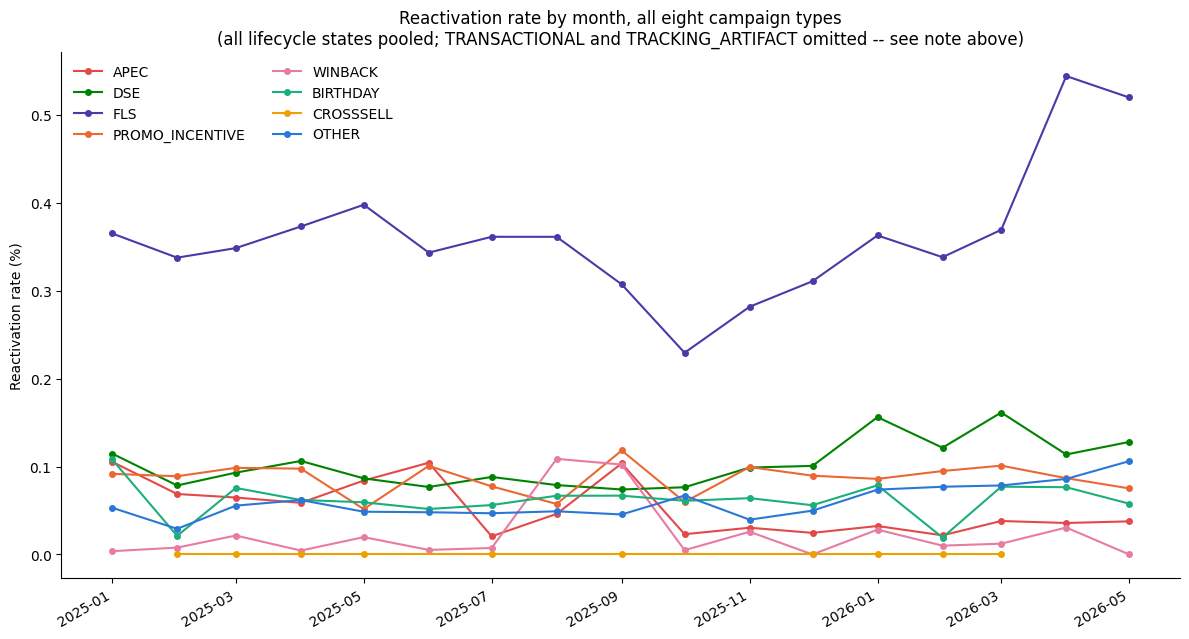

In [3]:
fig, ax = plt.subplots(figsize=(12, 6.5))

for cat in CAMPAIGN_TYPES:
    cat_df = category_monthly_df[category_monthly_df['campaign_category'] == cat].sort_values('month')
    ax.plot(
        cat_df['month'], cat_df['client_reactivation_rate'] * 100,
        marker='o', markersize=4, linewidth=1.5,
        color=CATEGORY_COLORS[cat], label=cat,
    )

ax.set_ylabel('Reactivation rate (%)')
ax.set_xlabel('')
ax.set_title('Reactivation rate by month, all eight campaign types\n(all lifecycle states pooled; TRANSACTIONAL and TRACKING_ARTIFACT omitted -- see note above)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncol=2)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Part 2 — Category reactivation trend over time, by client state

The same eight campaign types, now split into one panel per client state
instead of pooling everyone together. This checks whether a category's
trend -- and its ranking relative to the others -- holds consistently
within each state on its own, rather than being an artifact of one state's
volume dominating the pooled view above.

In [4]:
category_by_state_monthly_query = f"""--sql
WITH sends AS (
    SELECT client_id, sent_timestamp, send_utm_campaign, send_utm_content
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
state_at_send AS (
    SELECT
        s.client_id, s.sent_timestamp, s.send_utm_campaign, s.send_utm_content,
        CASE
            WHEN j.client_state_detail = 'Never Active' THEN 'Never Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {ACTIVE_MAX_DAYS} THEN 'Active'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
            WHEN date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
            ELSE 'Dormant 3+ yrs'
        END AS lifecycle_state
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
),
eligible_sends AS (
    SELECT * FROM state_at_send WHERE lifecycle_state NOT IN ('Never Active', 'Active')
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, send_utm_content, lifecycle_state,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%browseabandon%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%stylepass%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%styleprofile%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN regexp_like(send_utm_campaign, '(^|_)dse(_|$)') THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%cyl%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%offertest%' THEN 'PROMO_INCENTIVE'
            WHEN send_utm_campaign LIKE '%freestyle-lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign LIKE '%freestyle_lifecycle%' THEN 'FLS'
            WHEN send_utm_campaign = 'crumbs_has_app' THEN 'TRACKING_ARTIFACT'
            WHEN send_utm_campaign LIKE '%offer%' OR send_utm_campaign LIKE '%discount%'
              OR send_utm_campaign LIKE '%promo%' OR send_utm_campaign LIKE '%sale%'
              OR send_utm_campaign LIKE '%percentoff%' OR send_utm_campaign LIKE '%markdown%'
              OR send_utm_campaign LIKE '%deal%' OR send_utm_campaign LIKE '%coupon%'
              OR send_utm_campaign LIKE '%spendget%' OR send_utm_campaign LIKE '%lastchance%'
              OR send_utm_campaign LIKE '%credit%' OR send_utm_campaign LIKE '%incentive%'
              OR send_utm_campaign LIKE '%waivedstylingfee%'
            THEN 'PROMO_INCENTIVE'
            WHEN send_utm_campaign LIKE '%reactivation%' OR send_utm_campaign LIKE '%winback%'
            THEN 'WINBACK'
            WHEN send_utm_campaign LIKE '%birthday%'
            THEN 'BIRTHDAY'
            WHEN send_utm_campaign LIKE '%crossell%' OR send_utm_campaign LIKE '%crosssell%'
            THEN 'CROSSSELL'
            ELSE 'OTHER'
        END AS campaign_category
    FROM eligible_sends
),
matched_sessions AS (
    SELECT c.client_id, c.sent_timestamp, c.lifecycle_state, c.campaign_category, u.active_session_id
    FROM categorized_sends c
    INNER JOIN curated.user_session_conversion_metrics u
        ON u.client_id = c.client_id
        AND u.utm_source = 'blueshift'
        AND u.utm_content = c.send_utm_content
        AND u.datetime_in_utc >= c.sent_timestamp
        AND u.datetime_in_utc <  c.sent_timestamp + INTERVAL '{SESSION_ATTRIBUTION_WINDOW_DAYS}' DAY
    WHERE u.date_in_utc >= DATE '{START_DATE}'
),
attributed_demand AS (
    SELECT DISTINCT ms.client_id, ms.sent_timestamp, ms.lifecycle_state, ms.campaign_category
    FROM matched_sessions ms
    INNER JOIN curated.client_reactivation_demand_events e
        ON e.active_session_id = ms.active_session_id
    WHERE e.demand_type IN ('fix', 'direct_buy')
),
client_month_category AS (
    SELECT
        d.client_id,
        DATE_TRUNC('month', d.sent_timestamp) AS month,
        d.lifecycle_state,
        d.campaign_category,
        MAX(CASE WHEN a.client_id IS NOT NULL THEN 1 ELSE 0 END) AS client_reactivated
    FROM categorized_sends d
    LEFT JOIN attributed_demand a
        ON d.client_id = a.client_id
        AND d.sent_timestamp = a.sent_timestamp
        AND d.lifecycle_state = a.lifecycle_state
        AND d.campaign_category = a.campaign_category
    GROUP BY 1, 2, 3, 4
)
SELECT
    month,
    lifecycle_state,
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_category
GROUP BY 1, 2, 3
ORDER BY 2, 3, 1
"""

category_by_state_monthly_df = query(category_by_state_monthly_query)
category_by_state_monthly_df['month'] = pd.to_datetime(category_by_state_monthly_df['month'])
category_by_state_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


query() attempt 1/4 failed (DatabaseError: {'message': 'Encountered too many errors talking to a worker node. The node may have crashed or be under too much load. This is probably a transient issue, so please retry your query in a few minutes. (http://10.132.101.89:8080/v1/task/20260827_225414_06527_v96u8.13.6.4/results/34/0 - 202 failures, failure duration 300.17s, total failed request time 300.16s)', 'errorCode': 65540, 'errorName': 'PAGE_TRANSPORT_TIMEOUT', 'errorType': 'INTERNAL_ERROR', 'failureInfo': {'type': 'io.trino.operator.PageTransportTimeoutException', 'message': 'Encountered too many errors talking to a worker node. The node may have crashed or be under too much load. This is probably a transient issue, so please retry your query in a few minutes. (http://10.132.101.89:8080/v1/task/20260827_225414_06527_v96u8.13.6.4/results/34/0 - 202 failures, failure duration 300.17s, total failed request time 300.16s)', 'cause': {'type': 'java.io.UncheckedIOException', 'message': 'Faile

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,lifecycle_state,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,Dormant,APEC,654858,942,0.001438
1,2025-02-01,Dormant,APEC,638675,616,0.000964
2,2025-03-01,Dormant,APEC,633085,557,0.000880
3,2025-04-01,Dormant,APEC,617866,465,0.000753
4,2025-05-01,Dormant,APEC,604722,708,0.001171


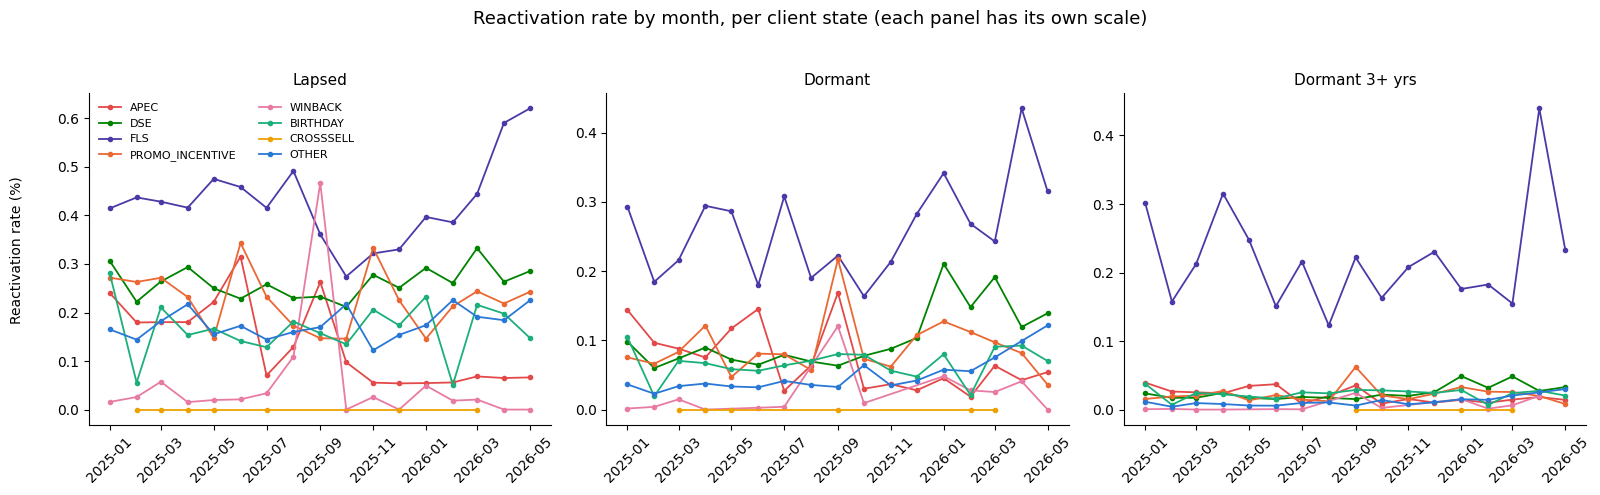

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for i, state in enumerate(LIFECYCLE_STATES):
    ax = axes[i]
    state_df = category_by_state_monthly_df[category_by_state_monthly_df['lifecycle_state'] == state]
    for cat in CAMPAIGN_TYPES:
        cat_df = state_df[state_df['campaign_category'] == cat].sort_values('month')
        ax.plot(
            cat_df['month'], cat_df['client_reactivation_rate'] * 100,
            marker='o', markersize=3, linewidth=1.3,
            color=CATEGORY_COLORS[cat], label=cat,
        )
    ax.set_title(state, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)

axes[0].legend(frameon=False, ncol=2, fontsize=8)
fig.suptitle('Reactivation rate by month, per client state (each panel has its own scale)', fontsize=13)
fig.text(0.0, 0.5, 'Reactivation rate (%)', va='center', rotation='vertical')
plt.tight_layout(rect=[0.02, 0, 1, 0.95])
plt.show()

## Part 3 — Campaign type deep dives: reactivation rate and send volume

For each of the eight campaign types below, two views:

- **Reactivation rate and send volume, all states combined** -- that
  category's own monthly reactivation rate and monthly unique-clients-sent
  count, side by side, pooling all three lifecycle states together.
- **Reactivation rate and send volume, by client state** -- the same two
  measures, now split into one row per lifecycle state.

Rate and volume are shown as two separate charts rather than one chart with
two scales, since they're different units (a percentage vs. a client
count) -- overlaying them on shared axes would misleadingly imply a shared
scale where none exists.

In [6]:
def plot_category_pooled(df, category):
    cat_df = df[df['campaign_category'] == category].sort_values('month')
    color = CATEGORY_COLORS[category]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(cat_df['month'], cat_df['client_reactivation_rate'] * 100, marker='o', markersize=5, linewidth=2, color=color)
    axes[0].set_title('Reactivation rate by month', fontsize=11)
    axes[0].set_ylabel('Reactivation rate (%)')
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].tick_params(axis='x', labelrotation=45)

    axes[1].plot(cat_df['month'], cat_df['unique_clients_sent'], marker='o', markersize=5, linewidth=2, color=color)
    axes[1].set_title('Unique clients sent by month', fontsize=11)
    axes[1].set_ylabel('Unique clients sent')
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].tick_params(axis='x', labelrotation=45)

    fig.suptitle(f'{category} -- all lifecycle states pooled', fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def plot_category_by_state(df, category):
    cat_df = df[df['campaign_category'] == category]
    color = CATEGORY_COLORS[category]

    fig, axes = plt.subplots(len(LIFECYCLE_STATES), 2, figsize=(12, 3.2 * len(LIFECYCLE_STATES)), sharex=True)

    for i, state in enumerate(LIFECYCLE_STATES):
        state_df = cat_df[cat_df['lifecycle_state'] == state].sort_values('month')
        ax_rate, ax_vol = axes[i]

        ax_rate.plot(state_df['month'], state_df['client_reactivation_rate'] * 100, marker='o', markersize=4, linewidth=1.5, color=color)
        ax_rate.set_ylabel(f'{state}\nRate (%)', fontsize=9)
        ax_rate.spines[['top', 'right']].set_visible(False)

        ax_vol.plot(state_df['month'], state_df['unique_clients_sent'], marker='o', markersize=4, linewidth=1.5, color=color)
        ax_vol.set_ylabel('Clients sent', fontsize=9)
        ax_vol.spines[['top', 'right']].set_visible(False)

    axes[0][0].set_title('Reactivation rate by month', fontsize=11)
    axes[0][1].set_title('Unique clients sent by month', fontsize=11)
    for ax in axes[-1]:
        ax.tick_params(axis='x', labelrotation=45)

    fig.suptitle(f'{category} -- by client state', fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### APEC

Algorithmic Personalized Email Content -- the personalization system this notebook family exists to evaluate, matched by campaign names containing "apec", plus its confirmed browse-abandon, StylePass, and style-profile triggers.

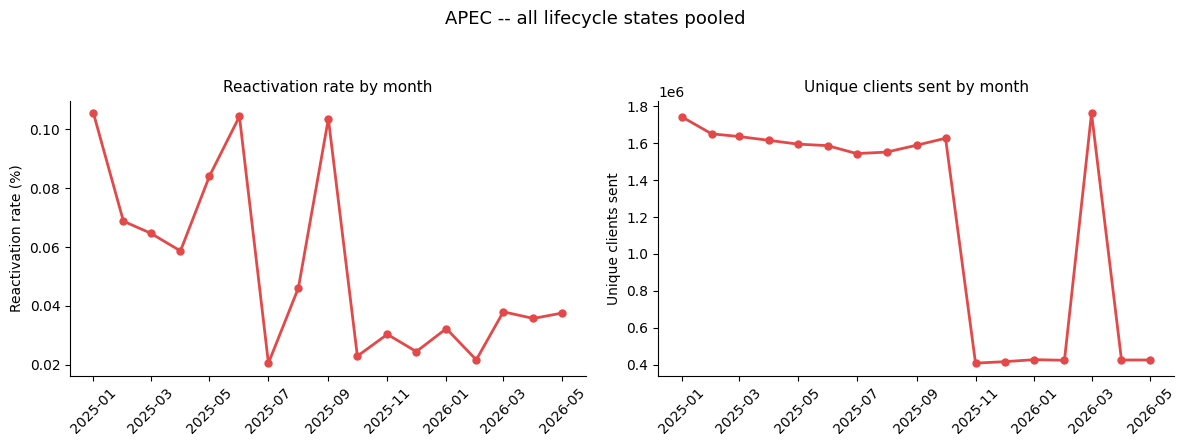

In [7]:
plot_category_pooled(category_monthly_df, 'APEC')

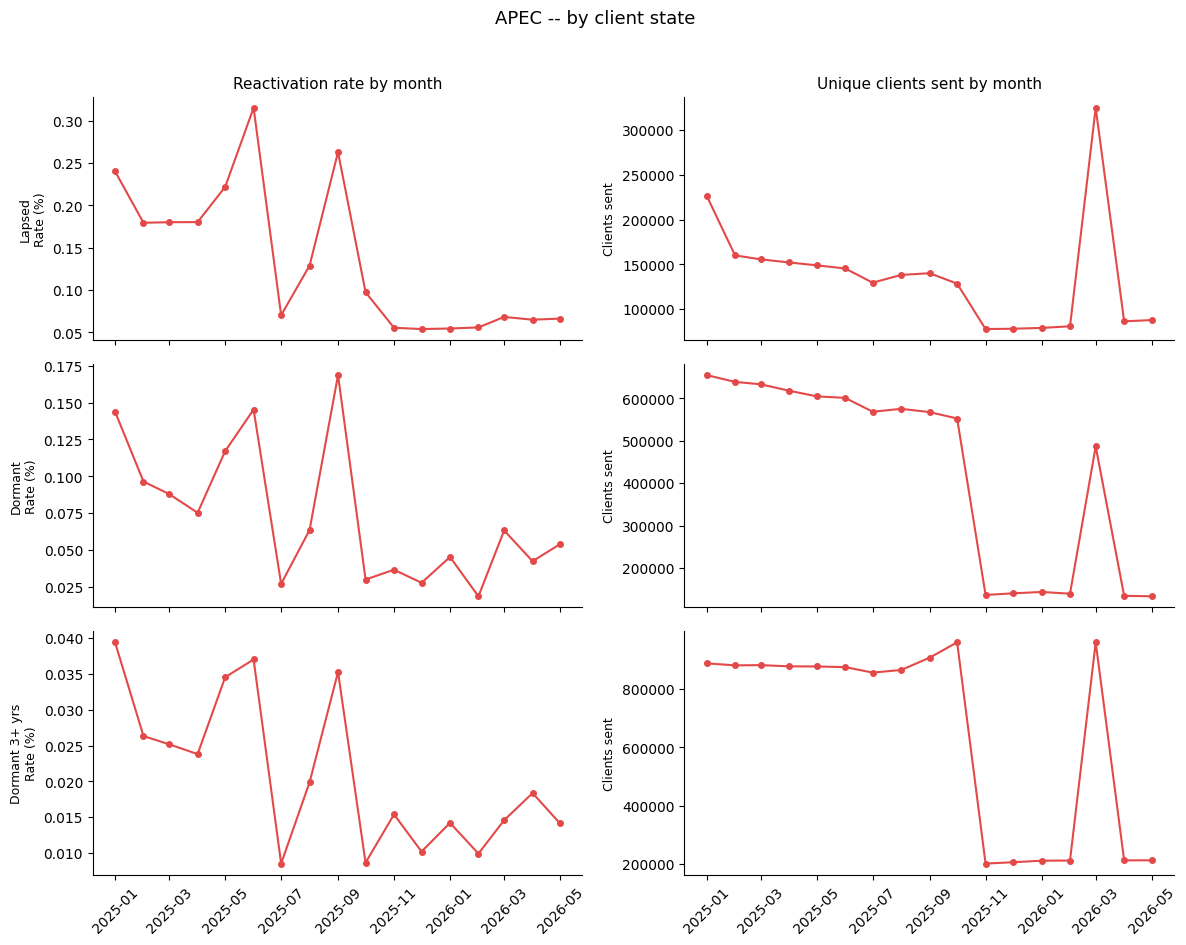

In [8]:
plot_category_by_state(category_by_state_monthly_df, 'APEC')

### DSE

Dynamic Shoppable Email -- dynamically assembled shoppable product content, including its TFY and CYL naming variants.

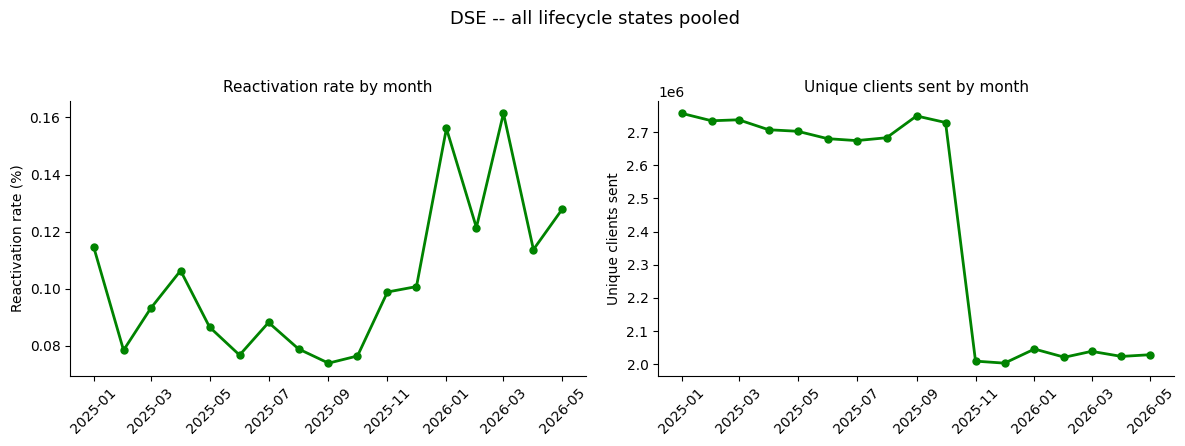

In [9]:
plot_category_pooled(category_monthly_df, 'DSE')

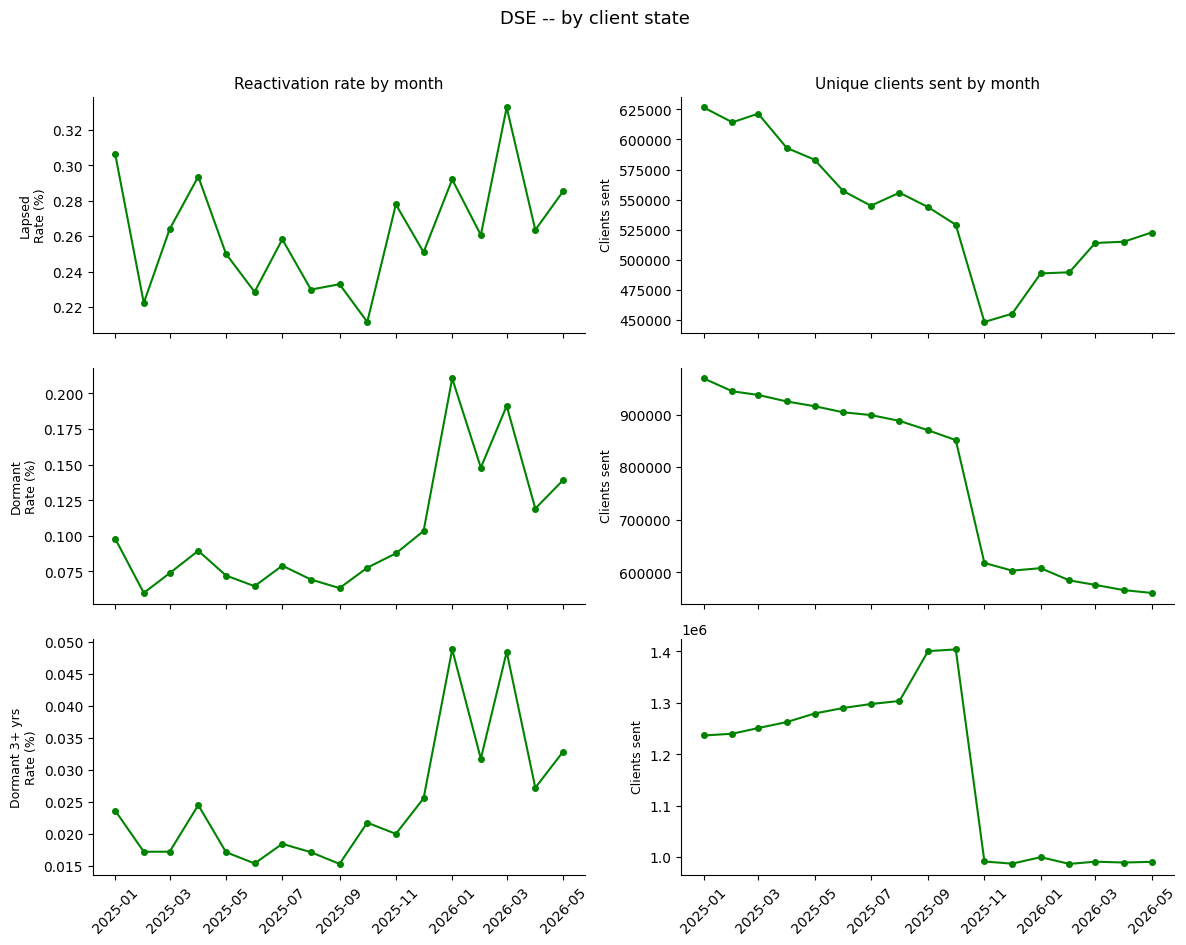

In [10]:
plot_category_by_state(category_by_state_monthly_df, 'DSE')

### FLS

Freestyle Lifecycle Series -- sends triggered by a specific high-intent behavioral event (cart abandonment, a saved item now on sale), not sent broadly like the others.

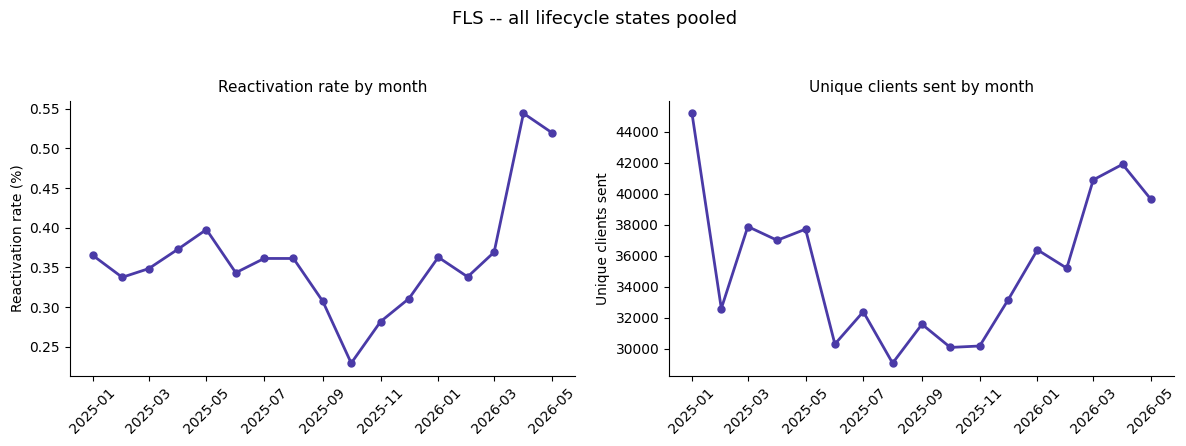

In [11]:
plot_category_pooled(category_monthly_df, 'FLS')

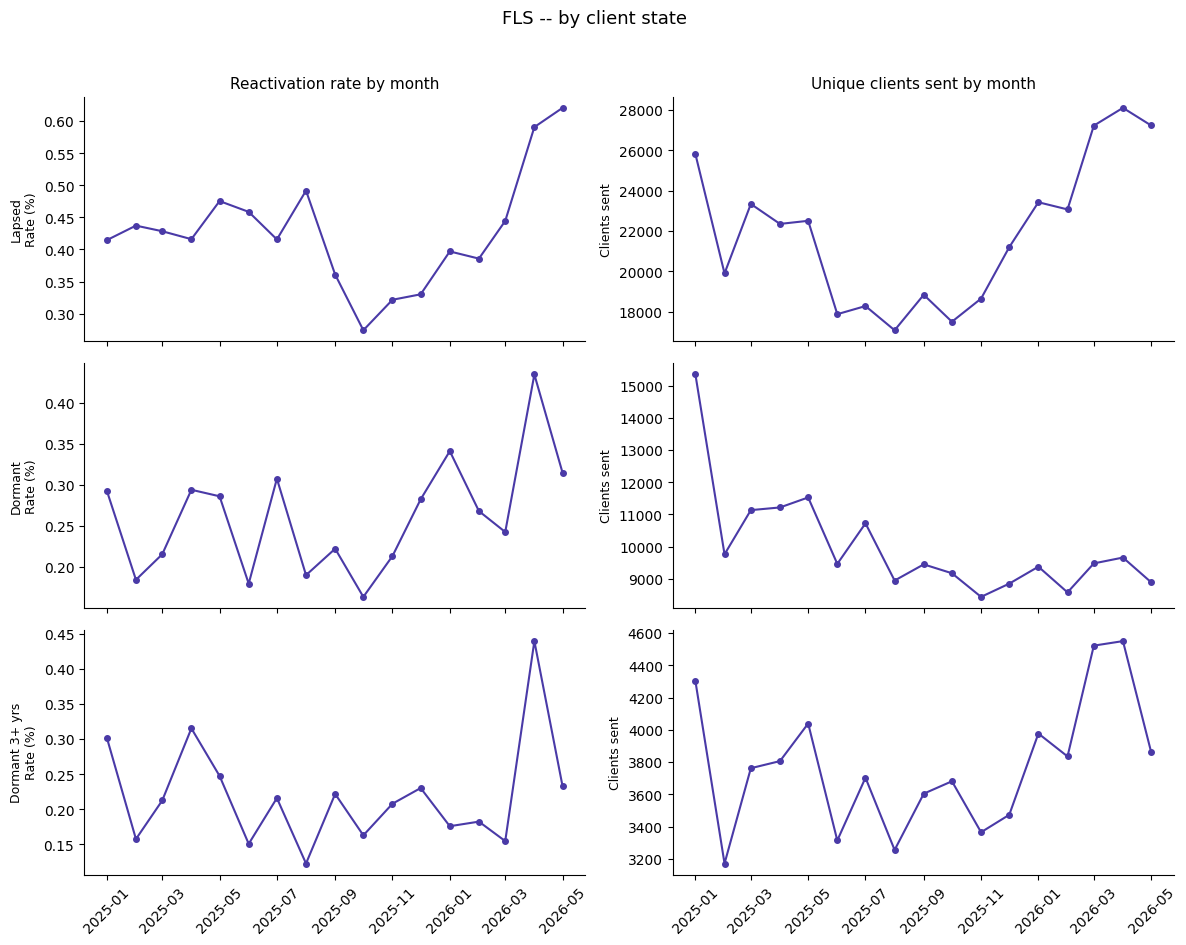

In [12]:
plot_category_by_state(category_by_state_monthly_df, 'FLS')

### PROMO_INCENTIVE

Campaigns using a financial incentive as the mechanism -- an offer, discount, sale, percent-off, markdown, deal, coupon, "spend X get Y" mechanic, credit, incentive, or waived styling fee.

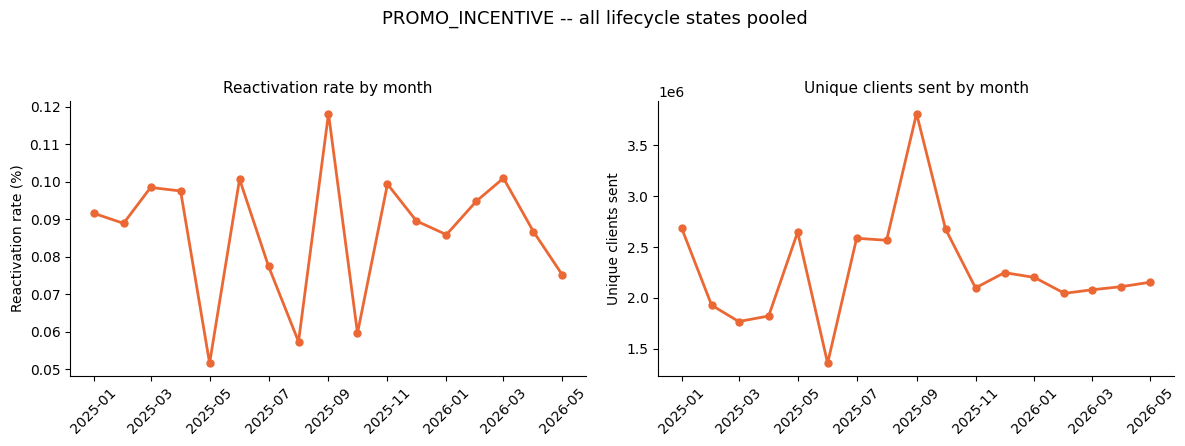

In [13]:
plot_category_pooled(category_monthly_df, 'PROMO_INCENTIVE')

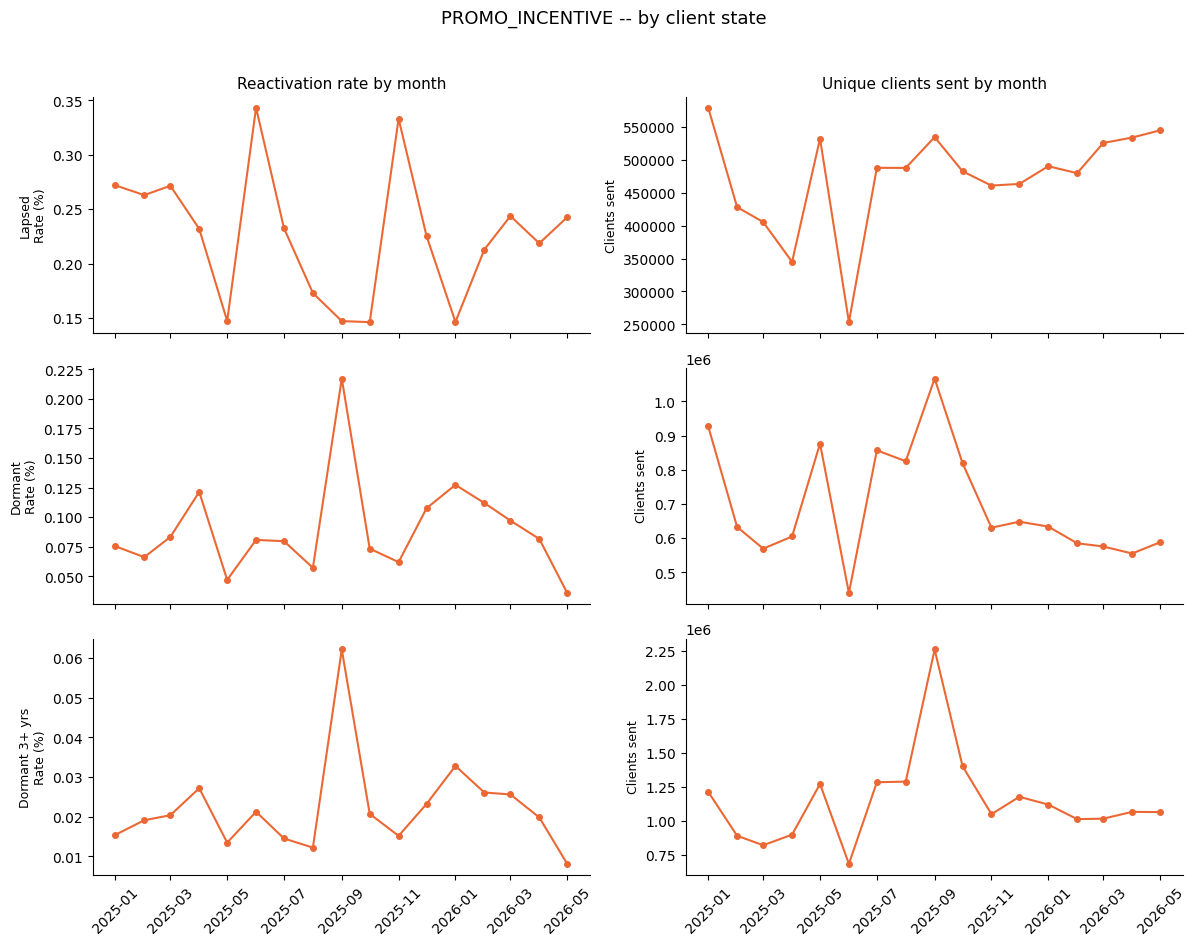

In [14]:
plot_category_by_state(category_by_state_monthly_df, 'PROMO_INCENTIVE')

### WINBACK

Reactivation/win-back branded messaging with no financial incentive attached -- a plain re-engagement message rather than an incentive-driven one.

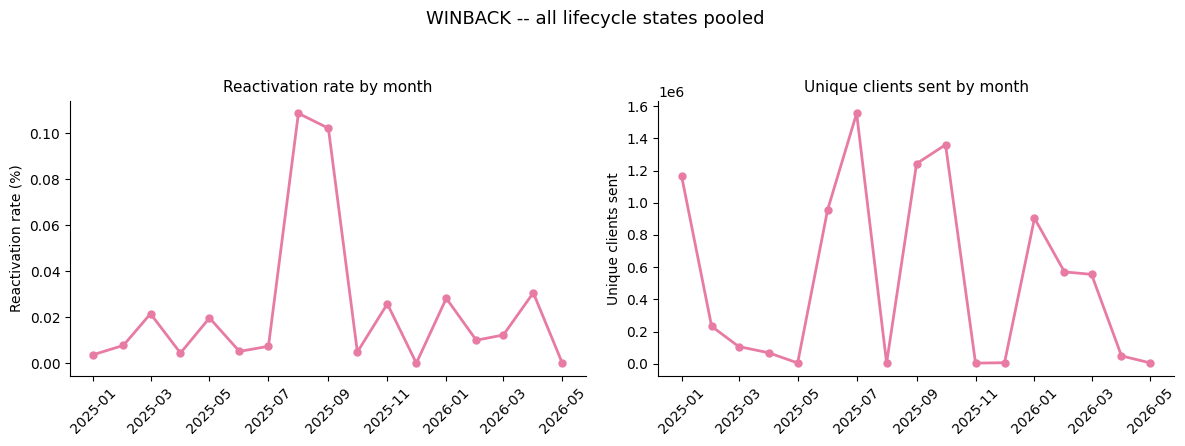

In [15]:
plot_category_pooled(category_monthly_df, 'WINBACK')

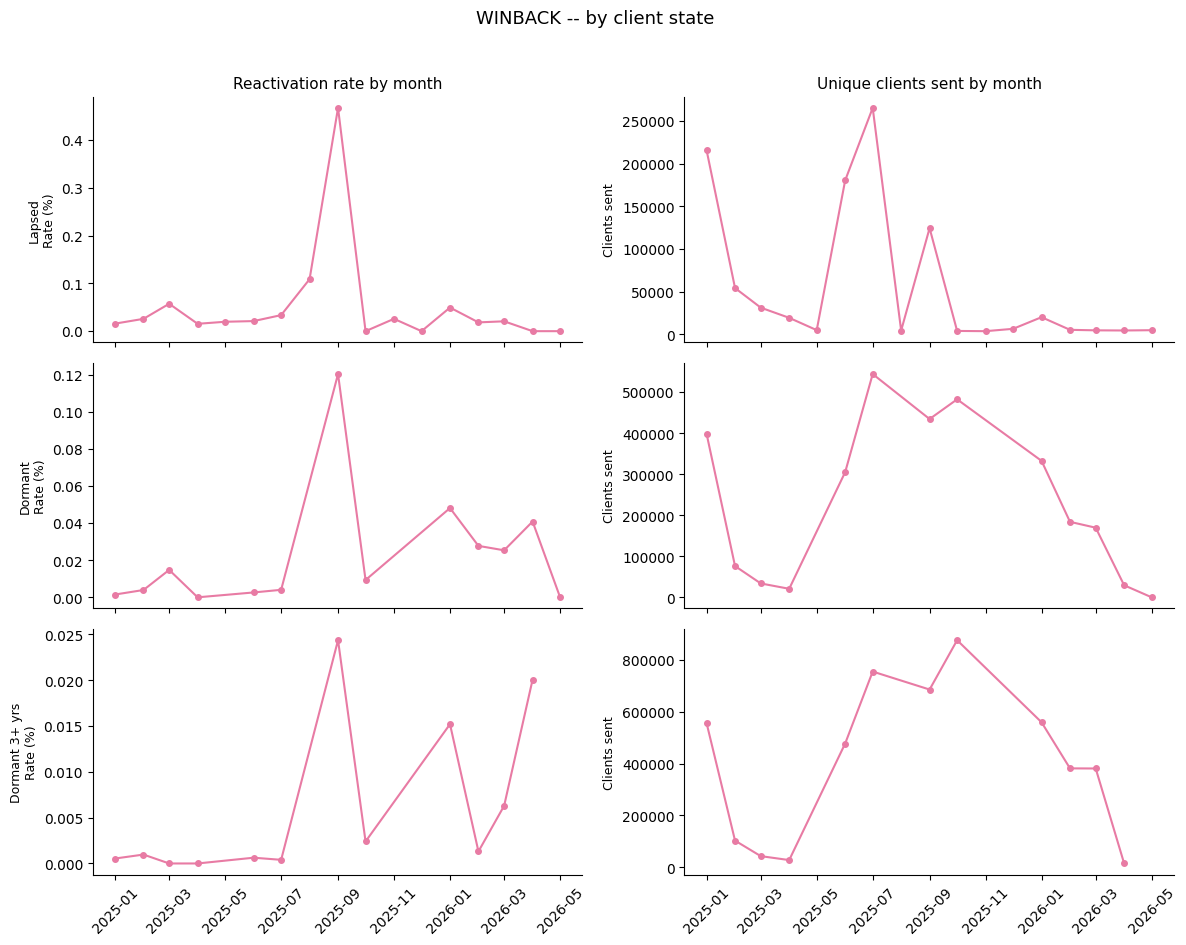

In [16]:
plot_category_by_state(category_by_state_monthly_df, 'WINBACK')

### BIRTHDAY

Birthday-triggered sends.

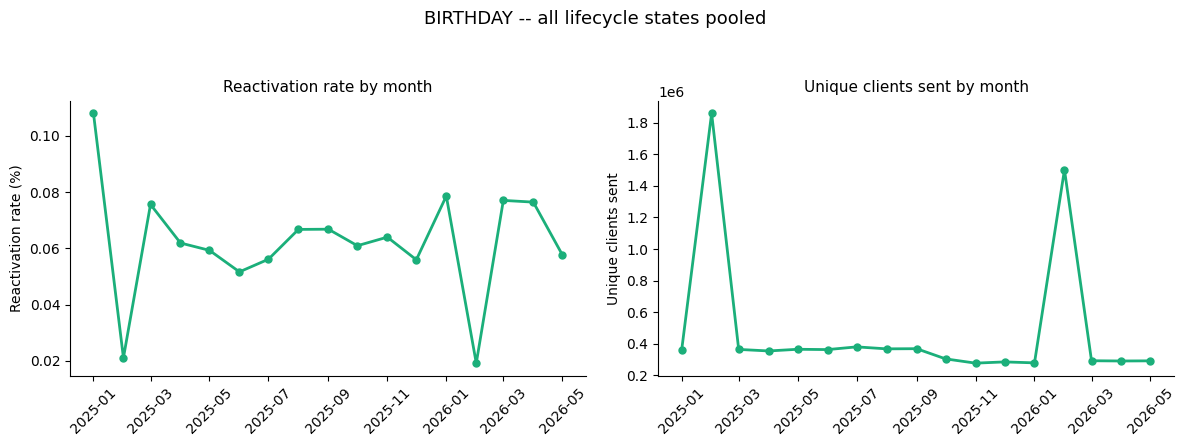

In [17]:
plot_category_pooled(category_monthly_df, 'BIRTHDAY')

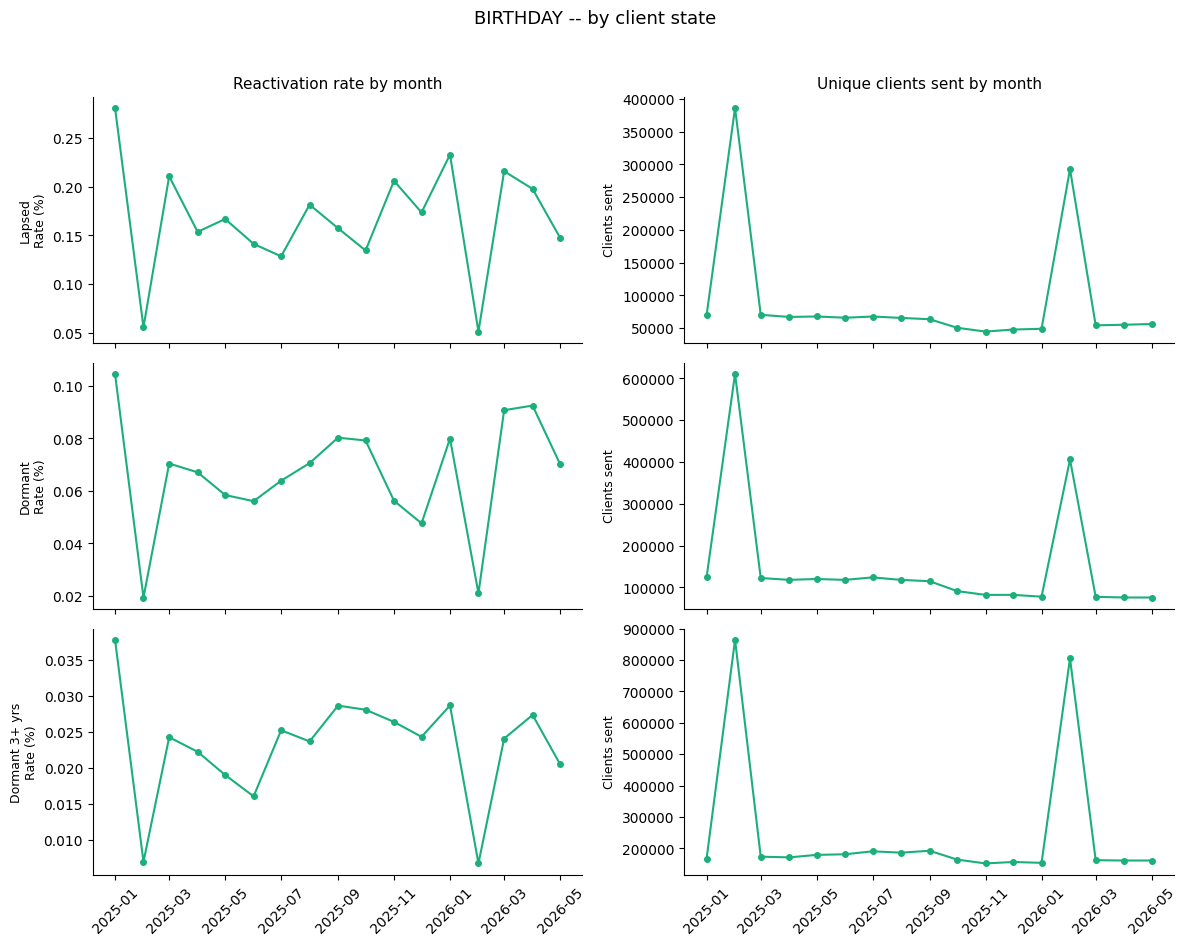

In [18]:
plot_category_by_state(category_by_state_monthly_df, 'BIRTHDAY')

### CROSSSELL

Post-Fix cross-sell sends.

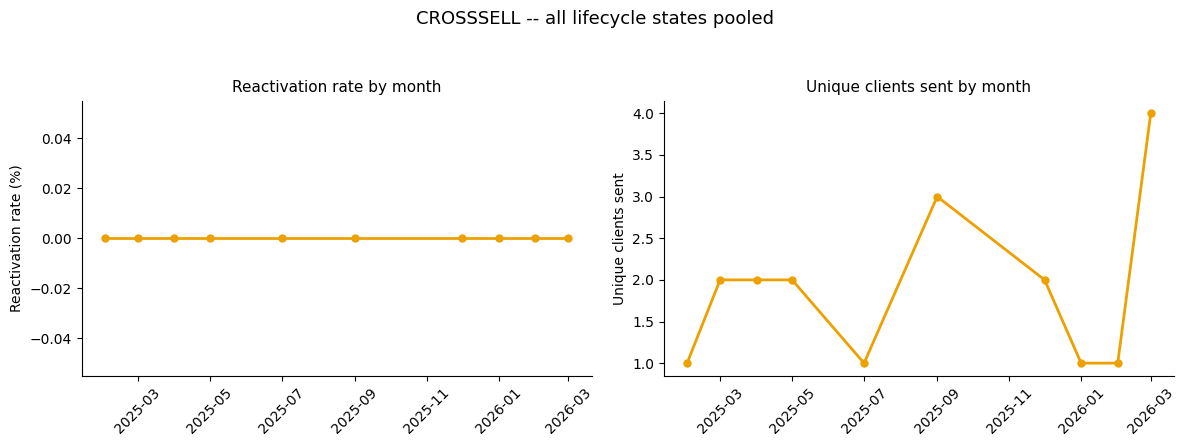

In [19]:
plot_category_pooled(category_monthly_df, 'CROSSSELL')

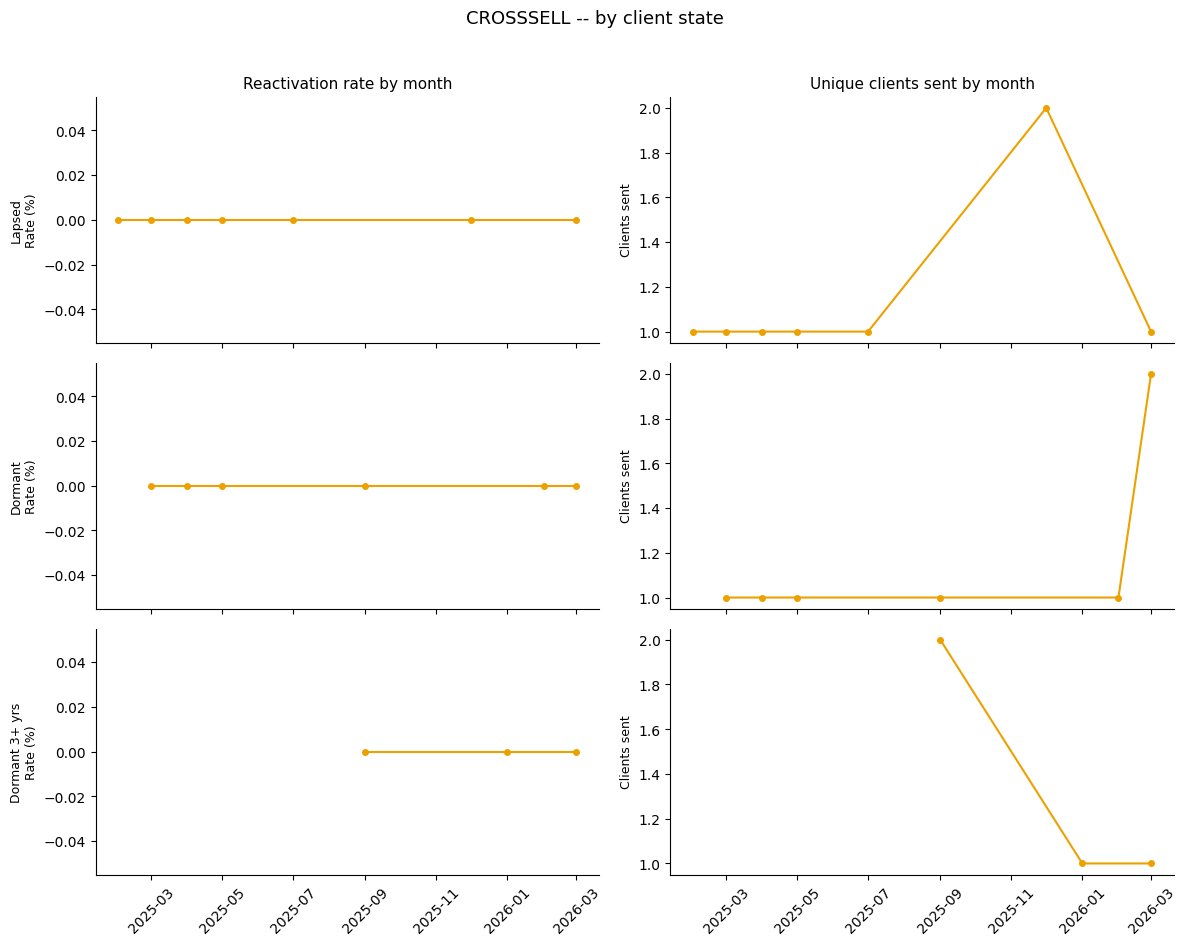

In [20]:
plot_category_by_state(category_by_state_monthly_df, 'CROSSSELL')

### OTHER

The true remainder after every identifiable sub-group above is removed -- generic seasonal, thematic, and welcome/onboarding marketing content with no personalization-, promotion-, or lifecycle-event-suggestive naming.

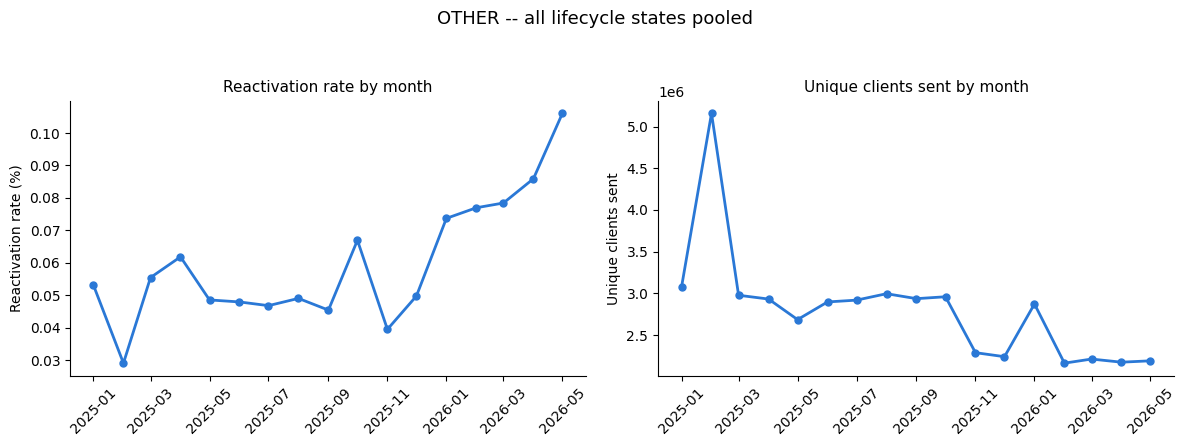

In [21]:
plot_category_pooled(category_monthly_df, 'OTHER')

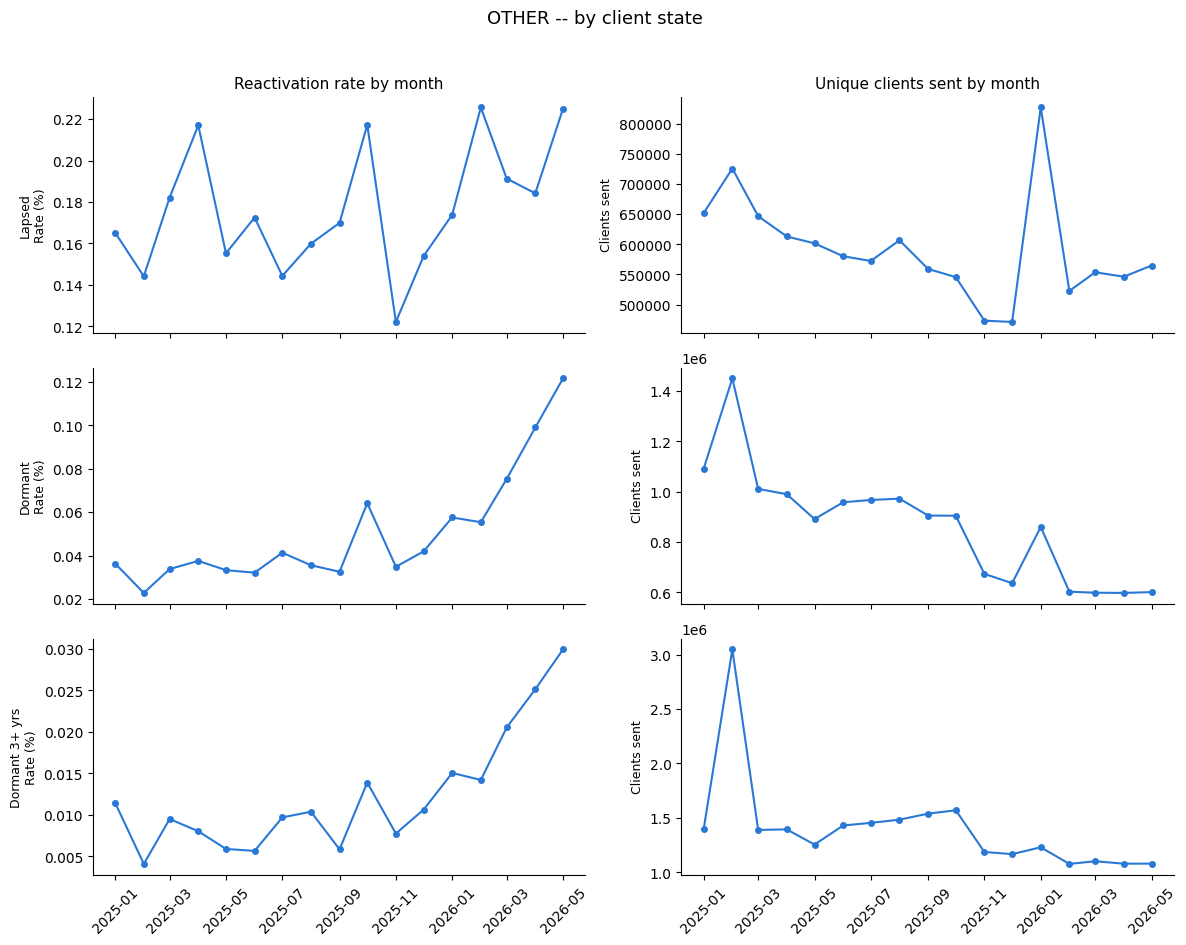

In [22]:
plot_category_by_state(category_by_state_monthly_df, 'OTHER')

## Limitations to keep in mind

- **Observational, not causal.** Nothing here is randomized. If different
  campaign categories reach different sub-segments of a population, are
  sent at different frequencies, or through different channels, some of
  any observed gap between categories could reflect those differences
  rather than the content or mechanism itself.
- **The reactivation metric is a lower bound.** It only counts reactivation
  with click-through evidence (a UTM-matched session leading to a real
  demand event). Real reactivations that happen through untracked paths
  aren't counted. This affects every category equally in principle, but
  the size of any undercount could differ across them if engagement
  patterns (e.g., app vs. email usage) differ by category or client state.
- **Campaign-name-based classification is inherently approximate.** No
  per-send flag confirms a campaign's true mechanism or intent; this
  notebook's categories are built from keyword patterns in
  `send_utm_campaign`, checked in a deliberate order to resolve the naming
  overlaps found during this analysis (see the classification table
  above). Some misclassification at the margins is still possible for
  campaign names that don't cleanly fit any pattern.
- **PROMO_INCENTIVE is a broad category by mechanism, not by campaign
  program.** It groups together every send that uses a financial incentive
  as its lever, regardless of which underlying program sent it (a one-time
  mass test, a standing reactivation offer, or a seasonal sale) -- these
  may not behave identically to one another, even though they're pooled
  here as a single comparison group.
- **WINBACK, BIRTHDAY, and CROSSSELL are comparatively low-volume.**
  CROSSSELL in particular has only 9 reactivated clients across the full
  17-month window -- its monthly, by-state breakdown will be mostly zero
  or undefined in many cells. That sparsity is itself informative (this
  send type essentially isn't driving reactivation in this population),
  but it also means month-to-month movements within it are not statistically
  reliable the way a higher-volume category's would be.
- **TRACKING_ARTIFACT is not a real send and is excluded from every
  cross-category comparison chart** (Parts 1-2), though it is still
  profiled on its own (Parts 3-4) for transparency -- it should read as a
  flat line at zero, confirming it carries no reactivation signal at all.
- **`END_DATE` relies on a 45-day maturity assumption that is not
  independently confirmed** for this notebook's data sources
  (`user_session_conversion_metrics`, `client_reactivation_demand_events`)
  -- the most recent 1-2 months in this window deserve slightly more
  caution than the rest.